# 2. Janus: CLIP для понимания, VQ для генерации

В ноутбуке 1 один и тот же VQ-токенизатор отвечал и за понимание входной картинки, и за генерацию выходной. Проблема: VQ-токены заточены под пиксельную реконструкцию, а не под семантику, и модели тяжело «понять», что на входе.

**Janus** (VLM от создателей DeepSeek) (https://arxiv.org/abs/2410.13848) разводит эти роли:
- **понимание** входной картинки → замороженный **CLIP** + обучаемый projector (непрерывные семантические эмбеддинги);
- **генерация** выходной картинки → дискретные **LlamaGen VQ**-токены (как в ноутбуке 1).

Сравнивая с предыдущим ноутбуков у нас будет что-то такое:  
`[эмбединги входной картинки] + [текстовые токены (инструкции/описания)] + [BOS, токены выходной картинки, EOS]`  

Или на картинке:  
![](https://i.ibb.co/ZpD6wyJ7/Screenshot-2026-06-03-at-16-03-12.png)

То есть теперь у нас даже не будет единого пространства токенов. Мы будет передавать с транформер сразу эмбединги clop пропущенные через адаптер!

In [ ]:
# %pip install requests matplotlib datasets transformers

In [1]:
import io, os, json, math, time, pickle, requests
from dataclasses import dataclass, field
from typing import List, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from datasets import load_dataset
from transformers import AutoTokenizer, CLIPVisionModel, CLIPImageProcessor
from huggingface_hub import hf_hub_download

os.environ["TOKENIZERS_PARALLELISM"] = "false"
torch.set_grad_enabled(False)   # включим только на обучении
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
print("device:", DEVICE)

device: cuda


## LlamaGen VQ-токенизатор (выход)

Тот же токенизатор, что в ноутбуке 1 (codebook 16384). Здесь он отвечает **только за выход**: кодирует целевую картинку в токены при обучении и декодирует предсказанные токены в пиксели.

In [ ]:
from dataclasses import dataclass, field
from typing import List

import torch
import torch.nn as nn
import torch.nn.functional as F


@dataclass
class ModelArgs:
    codebook_size: int = 16384
    codebook_embed_dim: int = 8
    codebook_l2_norm: bool = True
    codebook_show_usage: bool = True
    commit_loss_beta: float = 0.25
    entropy_loss_ratio: float = 0.0
    
    encoder_ch_mult: List[int] = field(default_factory=lambda: [1, 1, 2, 2, 4])
    decoder_ch_mult: List[int] = field(default_factory=lambda: [1, 1, 2, 2, 4])
    z_channels: int = 256
    dropout_p: float = 0.0



class VQModel(nn.Module):
    def __init__(self, config: ModelArgs):
        super().__init__()
        self.config = config
        self.encoder = Encoder(ch_mult=config.encoder_ch_mult, z_channels=config.z_channels, dropout=config.dropout_p)
        self.decoder = Decoder(ch_mult=config.decoder_ch_mult, z_channels=config.z_channels, dropout=config.dropout_p)

        self.quantize = VectorQuantizer(config.codebook_size, config.codebook_embed_dim, 
                                        config.commit_loss_beta, config.entropy_loss_ratio,
                                        config.codebook_l2_norm, config.codebook_show_usage)
        self.quant_conv = nn.Conv2d(config.z_channels, config.codebook_embed_dim, 1)
        self.post_quant_conv = nn.Conv2d(config.codebook_embed_dim, config.z_channels, 1)

    def encode(self, x):
        h = self.encoder(x)
        h = self.quant_conv(h)
        quant, emb_loss, info = self.quantize(h)
        return quant, emb_loss, info

    def decode(self, quant):
        quant = self.post_quant_conv(quant)
        dec = self.decoder(quant)
        return dec

    def decode_code(self, code_b, shape=None, channel_first=True):
        quant_b = self.quantize.get_codebook_entry(code_b, shape, channel_first)
        dec = self.decode(quant_b)
        return dec

    def forward(self, input):
        quant, diff, _ = self.encode(input)
        dec = self.decode(quant)
        return dec, diff



class Encoder(nn.Module):
    def __init__(self, in_channels=3, ch=128, ch_mult=(1,1,2,2,4), num_res_blocks=2, 
                 norm_type='group', dropout=0.0, resamp_with_conv=True, z_channels=256):
        super().__init__()
        self.num_resolutions = len(ch_mult)
        self.num_res_blocks = num_res_blocks
        self.conv_in = nn.Conv2d(in_channels, ch, kernel_size=3, stride=1, padding=1)

        # downsampling
        in_ch_mult = (1,) + tuple(ch_mult)
        self.conv_blocks = nn.ModuleList()
        for i_level in range(self.num_resolutions):
            conv_block = nn.Module()
            # res & attn
            res_block = nn.ModuleList()
            attn_block = nn.ModuleList()
            block_in = ch*in_ch_mult[i_level]
            block_out = ch*ch_mult[i_level]
            for _ in range(self.num_res_blocks):
                res_block.append(ResnetBlock(block_in, block_out, dropout=dropout, norm_type=norm_type))
                block_in = block_out
                if i_level == self.num_resolutions - 1:
                    attn_block.append(AttnBlock(block_in, norm_type))
            conv_block.res = res_block
            conv_block.attn = attn_block
            # downsample
            if i_level != self.num_resolutions-1:
                conv_block.downsample = Downsample(block_in, resamp_with_conv)
            self.conv_blocks.append(conv_block)

        # middle
        self.mid = nn.ModuleList()
        self.mid.append(ResnetBlock(block_in, block_in, dropout=dropout, norm_type=norm_type))
        self.mid.append(AttnBlock(block_in, norm_type=norm_type))
        self.mid.append(ResnetBlock(block_in, block_in, dropout=dropout, norm_type=norm_type))

        # end
        self.norm_out = Normalize(block_in, norm_type)
        self.conv_out = nn.Conv2d(block_in, z_channels, kernel_size=3, stride=1, padding=1)


    def forward(self, x):
        h = self.conv_in(x)
        # downsampling
        for i_level, block in enumerate(self.conv_blocks):
            for i_block in range(self.num_res_blocks):
                h = block.res[i_block](h)
                if len(block.attn) > 0:
                    h = block.attn[i_block](h)
            if i_level != self.num_resolutions - 1:
                h = block.downsample(h)
        
        # middle
        for mid_block in self.mid:
            h = mid_block(h)
        
        # end
        h = self.norm_out(h)
        h = nonlinearity(h)
        h = self.conv_out(h)
        return h



class Decoder(nn.Module):
    def __init__(self, z_channels=256, ch=128, ch_mult=(1,1,2,2,4), num_res_blocks=2, norm_type="group",
                 dropout=0.0, resamp_with_conv=True, out_channels=3):
        super().__init__()
        self.num_resolutions = len(ch_mult)
        self.num_res_blocks = num_res_blocks

        block_in = ch*ch_mult[self.num_resolutions-1]
        # z to block_in
        self.conv_in = nn.Conv2d(z_channels, block_in, kernel_size=3, stride=1, padding=1)

       # middle
        self.mid = nn.ModuleList()
        self.mid.append(ResnetBlock(block_in, block_in, dropout=dropout, norm_type=norm_type))
        self.mid.append(AttnBlock(block_in, norm_type=norm_type))
        self.mid.append(ResnetBlock(block_in, block_in, dropout=dropout, norm_type=norm_type))

        # upsampling
        self.conv_blocks = nn.ModuleList()
        for i_level in reversed(range(self.num_resolutions)):
            conv_block = nn.Module()
            # res & attn
            res_block = nn.ModuleList()
            attn_block = nn.ModuleList()
            block_out = ch*ch_mult[i_level]
            for _ in range(self.num_res_blocks + 1):
                res_block.append(ResnetBlock(block_in, block_out, dropout=dropout, norm_type=norm_type))
                block_in = block_out
                if i_level == self.num_resolutions - 1:
                    attn_block.append(AttnBlock(block_in, norm_type))
            conv_block.res = res_block
            conv_block.attn = attn_block
            # downsample
            if i_level != 0:
                conv_block.upsample = Upsample(block_in, resamp_with_conv)
            self.conv_blocks.append(conv_block)

        # end
        self.norm_out = Normalize(block_in, norm_type)
        self.conv_out = nn.Conv2d(block_in, out_channels, kernel_size=3, stride=1, padding=1)

    @property
    def last_layer(self):
        return self.conv_out.weight
    
    def forward(self, z):
        # z to block_in
        h = self.conv_in(z)

        # middle
        for mid_block in self.mid:
            h = mid_block(h)
        
        # upsampling
        for i_level, block in enumerate(self.conv_blocks):
            for i_block in range(self.num_res_blocks + 1):
                h = block.res[i_block](h)
                if len(block.attn) > 0:
                    h = block.attn[i_block](h)
            if i_level != self.num_resolutions - 1:
                h = block.upsample(h)

        # end
        h = self.norm_out(h)
        h = nonlinearity(h)
        h = self.conv_out(h)
        return h


class VectorQuantizer(nn.Module):
    def __init__(self, n_e, e_dim, beta, entropy_loss_ratio, l2_norm, show_usage):
        super().__init__()
        self.n_e = n_e
        self.e_dim = e_dim
        self.beta = beta
        self.entropy_loss_ratio = entropy_loss_ratio
        self.l2_norm = l2_norm
        self.show_usage = show_usage

        self.embedding = nn.Embedding(self.n_e, self.e_dim)
        self.embedding.weight.data.uniform_(-1.0 / self.n_e, 1.0 / self.n_e)
        if self.l2_norm:
            self.embedding.weight.data = F.normalize(self.embedding.weight.data, p=2, dim=-1)
        if self.show_usage:
            self.register_buffer("codebook_used", nn.Parameter(torch.zeros(65536)))

    
    def forward(self, z):
        # reshape z -> (batch, height, width, channel) and flatten
        z = torch.einsum('b c h w -> b h w c', z).contiguous()
        z_flattened = z.view(-1, self.e_dim)
        # distances from z to embeddings e_j (z - e)^2 = z^2 + e^2 - 2 e * z

        if self.l2_norm:
            z = F.normalize(z, p=2, dim=-1)
            z_flattened = F.normalize(z_flattened, p=2, dim=-1)
            embedding = F.normalize(self.embedding.weight, p=2, dim=-1)
        else:
            embedding = self.embedding.weight

        d = torch.sum(z_flattened ** 2, dim=1, keepdim=True) + \
            torch.sum(embedding**2, dim=1) - 2 * \
            torch.einsum('bd,dn->bn', z_flattened, torch.einsum('n d -> d n', embedding))

        min_encoding_indices = torch.argmin(d, dim=1)
        z_q = embedding[min_encoding_indices].view(z.shape)
        perplexity = None
        min_encodings = None
        vq_loss = None
        commit_loss = None
        entropy_loss = None
        codebook_usage = 0

        if self.show_usage and self.training:
            cur_len = min_encoding_indices.shape[0]
            self.codebook_used[:-cur_len] = self.codebook_used[cur_len:].clone()
            self.codebook_used[-cur_len:] = min_encoding_indices
            codebook_usage = len(torch.unique(self.codebook_used)) / self.n_e

        # compute loss for embedding
        if self.training:
            vq_loss = torch.mean((z_q - z.detach()) ** 2) 
            commit_loss = self.beta * torch.mean((z_q.detach() - z) ** 2) 
            entropy_loss = self.entropy_loss_ratio * compute_entropy_loss(-d)

        # preserve gradients
        z_q = z + (z_q - z).detach()

        # reshape back to match original input shape
        z_q = torch.einsum('b h w c -> b c h w', z_q)

        return z_q, (vq_loss, commit_loss, entropy_loss, codebook_usage), (perplexity, min_encodings, min_encoding_indices)

    def get_codebook_entry(self, indices, shape=None, channel_first=True):
        # shape = (batch, channel, height, width) if channel_first else (batch, height, width, channel)
        if self.l2_norm:
            embedding = F.normalize(self.embedding.weight, p=2, dim=-1)
        else:
            embedding = self.embedding.weight
        z_q = embedding[indices]  # (b*h*w, c)

        if shape is not None:
            if channel_first:
                z_q = z_q.reshape(shape[0], shape[2], shape[3], shape[1])
                # reshape back to match original input shape
                z_q = z_q.permute(0, 3, 1, 2).contiguous()
            else:
                z_q = z_q.view(shape)
        return z_q


class ResnetBlock(nn.Module):
    def __init__(self, in_channels, out_channels=None, conv_shortcut=False, dropout=0.0, norm_type='group'):
        super().__init__()
        self.in_channels = in_channels
        out_channels = in_channels if out_channels is None else out_channels
        self.out_channels = out_channels
        self.use_conv_shortcut = conv_shortcut

        self.norm1 = Normalize(in_channels, norm_type)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.norm2 = Normalize(out_channels, norm_type)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)

        if self.in_channels != self.out_channels:
            if self.use_conv_shortcut:
                self.conv_shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
            else:
                self.nin_shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        h = x
        h = self.norm1(h)
        h = nonlinearity(h)
        h = self.conv1(h)
        h = self.norm2(h)
        h = nonlinearity(h)
        h = self.dropout(h)
        h = self.conv2(h)

        if self.in_channels != self.out_channels:
            if self.use_conv_shortcut:
                x = self.conv_shortcut(x)
            else:
                x = self.nin_shortcut(x)
        return x+h


class AttnBlock(nn.Module):
    def __init__(self, in_channels, norm_type='group'):
        super().__init__()
        self.norm = Normalize(in_channels, norm_type)
        self.q = nn.Conv2d(in_channels, in_channels, kernel_size=1, stride=1, padding=0)
        self.k = nn.Conv2d(in_channels, in_channels, kernel_size=1, stride=1, padding=0)
        self.v = nn.Conv2d(in_channels, in_channels, kernel_size=1, stride=1, padding=0)
        self.proj_out = nn.Conv2d(in_channels, in_channels, kernel_size=1, stride=1, padding=0)


    def forward(self, x):
        h_ = x
        h_ = self.norm(h_)
        q = self.q(h_)
        k = self.k(h_)
        v = self.v(h_)

        # compute attention
        b,c,h,w = q.shape
        q = q.reshape(b,c,h*w)
        q = q.permute(0,2,1)   # b,hw,c
        k = k.reshape(b,c,h*w) # b,c,hw
        w_ = torch.bmm(q,k)     # b,hw,hw    w[b,i,j]=sum_c q[b,i,c]k[b,c,j]
        w_ = w_ * (int(c)**(-0.5))
        w_ = F.softmax(w_, dim=2)

        # attend to values
        v = v.reshape(b,c,h*w)
        w_ = w_.permute(0,2,1)   # b,hw,hw (first hw of k, second of q)
        h_ = torch.bmm(v,w_)     # b, c,hw (hw of q) h_[b,c,j] = sum_i v[b,c,i] w_[b,i,j]
        h_ = h_.reshape(b,c,h,w)

        h_ = self.proj_out(h_)

        return x+h_


def nonlinearity(x):
    # swish
    return x*torch.sigmoid(x)


def Normalize(in_channels, norm_type='group'):
    assert norm_type in ['group', 'batch']
    if norm_type == 'group':
        return nn.GroupNorm(num_groups=32, num_channels=in_channels, eps=1e-6, affine=True)
    elif norm_type == 'batch':
        return nn.SyncBatchNorm(in_channels)


class Upsample(nn.Module):
    def __init__(self, in_channels, with_conv):
        super().__init__()
        self.with_conv = with_conv
        if self.with_conv:
            self.conv = nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2.0, mode="nearest")
        if self.with_conv:
            x = self.conv(x)
        return x


class Downsample(nn.Module):
    def __init__(self, in_channels, with_conv):
        super().__init__()
        self.with_conv = with_conv
        if self.with_conv:
            # no asymmetric padding in torch conv, must do it ourselves
            self.conv = nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=2, padding=0)

    def forward(self, x):
        if self.with_conv:
            pad = (0,1,0,1)
            x = F.pad(x, pad, mode="constant", value=0)
            x = self.conv(x)
        else:
            x = F.avg_pool2d(x, kernel_size=2, stride=2)
        return x


def compute_entropy_loss(affinity, loss_type="softmax", temperature=0.01):
    flat_affinity = affinity.reshape(-1, affinity.shape[-1])
    flat_affinity /= temperature
    probs = F.softmax(flat_affinity, dim=-1)
    log_probs = F.log_softmax(flat_affinity + 1e-5, dim=-1)
    if loss_type == "softmax":
        target_probs = probs
    else:
        raise ValueError("Entropy loss {} not supported".format(loss_type))
    avg_probs = torch.mean(target_probs, dim=0)
    avg_entropy = - torch.sum(avg_probs * torch.log(avg_probs + 1e-5))
    sample_entropy = - torch.mean(torch.sum(target_probs * log_probs, dim=-1))
    loss = sample_entropy - avg_entropy
    return loss


#################################################################################
#                              VQ Model Configs                                 #
#################################################################################
def VQ_8(**kwargs):
    return VQModel(ModelArgs(encoder_ch_mult=[1, 2, 2, 4], decoder_ch_mult=[1, 2, 2, 4], **kwargs))

def VQ_16(**kwargs):
    return VQModel(ModelArgs(encoder_ch_mult=[1, 1, 2, 2, 4], decoder_ch_mult=[1, 1, 2, 2, 4], **kwargs))

VQ_models = {'VQ-16': VQ_16, 'VQ-8': VQ_8}

Загрузка весов + хелперы препроцессинга/реконструкции.

In [3]:
def load_llamagen_vq(device=DEVICE, codebook_size=16384, codebook_embed_dim=8):
    model = VQ_models["VQ-16"](codebook_size=codebook_size, codebook_embed_dim=codebook_embed_dim)
    ckpt_path = hf_hub_download(repo_id="FoundationVision/LlamaGen", filename="vq_ds16_c2i.pt")
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    sd = ckpt.get("ema") or ckpt.get("model") or ckpt.get("state_dict") or ckpt
    model.load_state_dict(sd)
    return model.eval().to(device)


vq = load_llamagen_vq()
VQ_CODEBOOK = vq.config.codebook_size       # 16384
VQ_EDIM = vq.config.codebook_embed_dim      # 8
N_IMG_TOKENS = 16 * 16                       # 256x256 -> 16x16
print(f"LlamaGen VQ: codebook={VQ_CODEBOOK}, embed_dim={VQ_EDIM}, tokens/image={N_IMG_TOKENS}")


def center_crop_arr(pil_image, image_size):
    while min(*pil_image.size) >= 2 * image_size:
        pil_image = pil_image.resize(tuple(x // 2 for x in pil_image.size), resample=Image.BOX)
    scale = image_size / min(*pil_image.size)
    pil_image = pil_image.resize(tuple(round(x * scale) for x in pil_image.size), resample=Image.BICUBIC)
    arr = np.array(pil_image)
    cy = (arr.shape[0] - image_size) // 2
    cx = (arr.shape[1] - image_size) // 2
    return Image.fromarray(arr[cy:cy + image_size, cx:cx + image_size])


def custom_to_pil(x):
    x = torch.clamp(x.detach().cpu(), -1.0, 1.0)
    x = (x + 1.0) / 2.0
    x = (255 * x.permute(1, 2, 0).numpy()).astype(np.uint8)
    return Image.fromarray(x).convert("RGB")


@torch.no_grad()
def lg_encode_indices(pil, image_size=256):
    crop = center_crop_arr(pil.convert("RGB"), image_size)
    arr = np.array(crop) / 255.0
    x = torch.tensor(2.0 * arr - 1.0).unsqueeze(0)          # [-1, 1] -- так обучался VQ
    x = torch.einsum("nhwc->nchw", x).float().to(DEVICE)
    _, _, [_, _, idx] = vq.encode(x)
    return idx.cpu().numpy()                                # (256,) индексы codebook


@torch.no_grad()
def lg_decode_to_pil(indices, grid=16):
    idx = torch.as_tensor(indices, dtype=torch.long, device=DEVICE).reshape(-1)
    dec = vq.decode_code(idx, shape=(1, VQ_EDIM, grid, grid))
    return custom_to_pil(dec[0])

LlamaGen VQ: codebook=16384, embed_dim=8, tokens/image=256


Быстрая проверка токенизатора.

tokens: 256 | codebook: 16384


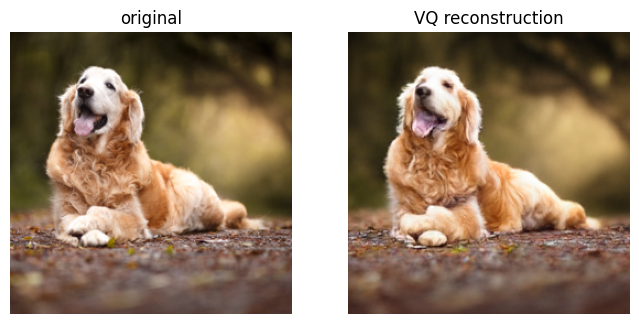

In [4]:
_demo = Image.open(requests.get(
    "https://pettownsendvet.com/wp-content/uploads/2023/01/iStock-1052880600-2048x1365.jpg",
    stream=True).raw)
_idx = lg_encode_indices(_demo)
_rec = lg_decode_to_pil(_idx)
print("tokens:", len(_idx), "| codebook:", VQ_CODEBOOK)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(center_crop_arr(_demo.convert("RGB"), 256)); ax[0].set_title("original"); ax[0].axis("off")
ax[1].imshow(_rec); ax[1].set_title("VQ reconstruction"); ax[1].axis("off")
plt.show()

Тот же самый ретривер так как эта модель не поменялась, но при обучении модель не будет "видеть" картинку таким образом. Она будет видеть только эмбединги клипа и пытаться научиться связывать их с токенами VQ при генерации

## CLIP — энкодер понимания (вход)

Замороженный **CLIP ViT-B/32**: картинка 224×224 → сетка 7×7 = 49 патч-эмбеддингов размерности 768. Это **семантические** признаки («что на картинке»), а не пиксельные. Обучаемый projector приведёт их к размерности LLM, и они пойдут в трансформер как «мягкие токены» — никаких индексов словаря для входной картинки.

In [5]:
CLIP_NAME = "openai/clip-vit-base-patch32"        # 224 -> 7x7 = 49 патчей, dim 768
clip_processor = CLIPImageProcessor.from_pretrained(CLIP_NAME)
clip_vision = CLIPVisionModel.from_pretrained(CLIP_NAME).eval().to(DEVICE)
for p in clip_vision.parameters():
    p.requires_grad = False                       # CLIP заморожен; учим только projector + LLM
CLIP_DIM = clip_vision.config.hidden_size         # 768
print(f"CLIP: {CLIP_NAME} | hidden={CLIP_DIM} | patches=49")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.final_layer_norm.weight        

CLIP: openai/clip-vit-base-patch32 | hidden=768 | patches=49


## Данные: InstructPix2Pix

Те же данные

In [8]:
DATA_DIR = "./data_janus"
N_SAMPLES = 20000

def download_data(data_dir=DATA_DIR, n=N_SAMPLES):
    img_dir, pr_dir = f"{data_dir}/images", f"{data_dir}/prompts"
    if os.path.isdir(img_dir) and len(os.listdir(img_dir)) >= 2 * n:
        print("data already downloaded"); return
    os.makedirs(img_dir, exist_ok=True); os.makedirs(pr_dir, exist_ok=True)
    ds = load_dataset("timbrooks/instructpix2pix-clip-filtered", split="train", streaming=True)
    for i, e in enumerate(tqdm(ds, total=n)):
        if i >= n: break
        e["original_image"].save(f"{img_dir}/{i}_original.png")
        e["edited_image"].save(f"{img_dir}/{i}_edited.png")
        json.dump({"original_prompt": e["original_prompt"], "edit_prompt": e["edit_prompt"]},
                  open(f"{pr_dir}/{i}_prompt.json", "w"))
    print("downloaded", n)


download_data()

Resolving data files:   0%|          | 0/262 [00:00<?, ?it/s]

  0%|          | 0/20000 [00:00<?, ?it/s]

downloaded 20000


## Токенизация в кэш (только целевые картинки)

В отличие от ноутбука 1, кэшируем токены **только отредактированной** картинки (цель генерации). Исходную картинку не токенизируем — она пойдёт в CLIP как пиксели на лету. 

In [9]:
def build_token_cache(data_dir=DATA_DIR, image_size=256):
    pkl_dir = f"{data_dir}/pickles"; os.makedirs(pkl_dir, exist_ok=True)
    ids = sorted(int(f.split("_")[0]) for f in os.listdir(f"{data_dir}/prompts") if f.endswith("json"))
    for item in tqdm(ids):
        dst = f"{pkl_dir}/{item}.pkl"
        if os.path.exists(dst): continue
        pr = json.load(open(f"{data_dir}/prompts/{item}_prompt.json"))
        text = f"Original image description: {pr['original_prompt']}; Prompt: {pr['edit_prompt']}; Answer:"
        edit = lg_encode_indices(Image.open(f"{data_dir}/images/{item}_edited.png"), image_size)
        pickle.dump({"edited_image": edit, "text_data": text}, open(dst, "wb"))
    print("cached", len(ids))


build_token_cache()

  0%|          | 0/20000 [00:00<?, ?it/s]

cached 20000


## Датасет и коллатор

Датасет отдаёт `pixel_values` исходной картинки (для CLIP) + токены целевой + текст. Коллатор пакует **только** `[текст] + [токены целевой картинки]` (исходная картинка идёт отдельным каналом `pixel_values`). Префикс CLIP-эмбеддингов добавляется уже в `forward`.

In [10]:
class JanusEditDataset(Dataset):
    def __init__(self, data_dir, clip_processor, start=None, end=None):
        ids = sorted(int(f.split(".")[0]) for f in os.listdir(f"{data_dir}/pickles") if f.endswith("pkl"))
        self.ids = ids[start:end]; self.data_dir = data_dir; self.clip_processor = clip_processor

    def __len__(self): return len(self.ids)

    def __getitem__(self, i):
        item = self.ids[i]
        d = pickle.load(open(f"{self.data_dir}/pickles/{item}.pkl", "rb"))
        orig = Image.open(f"{self.data_dir}/images/{item}_original.png").convert("RGB")
        pix = self.clip_processor(images=orig, return_tensors="pt")["pixel_values"][0]
        return {"pixel_values": pix, "target_tokens": d["edited_image"], "text": d["text_data"]}


class JanusCollator:
    def __init__(self, tokenizer, max_text_len=64):
        self.tok = tokenizer
        self.offset = tokenizer.vocab_size      # визуальные токены выше текстовых
        self.max_text = max_text_len

    def __call__(self, batch):
        pixel_values = torch.stack([b["pixel_values"] for b in batch])
        texts = self.tok([b["text"] for b in batch], truncation=True, max_length=self.max_text)["input_ids"]
        input_ids, labels = [], []
        for b, t_ids in zip(batch, texts):
            edit = (np.asarray(b["target_tokens"]).reshape(-1) + self.offset).tolist()
            seq = t_ids + edit
            lab = [-100] * len(seq)
            start_ed = len(t_ids)
            # next-token: logits[j-1] предсказывает seq[j]; учим только на целевой картинке
            for j in range(start_ed, len(seq)):
                lab[j - 1] = seq[j]
            input_ids.append(seq); labels.append(lab)

        maxlen = max(len(x) for x in input_ids); pad = self.tok.pad_token_id
        attn = [[1] * len(x) + [0] * (maxlen - len(x)) for x in input_ids]
        input_ids = [x + [pad] * (maxlen - len(x)) for x in input_ids]
        labels = [x + [-100] * (maxlen - len(x)) for x in labels]
        return {
            "pixel_values": pixel_values,
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attn, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
        }

## Языковая модель

Тот же Llama-подобный декодер (SmolLM2-135M). Отличие от ноутбука 1: `lm_use_tokens=False` — модель принимает **эмбеддинги** (часть входа — непрерывные CLIP-фичи), а голову применяем вручную в VLM. Словарь по-прежнему расширен на codebook (`49152 + 16384`), потому что **выходные** токены картинки предсказываются головой LLM.

In [11]:
def top_k_top_p_filtering(logits, top_k=0, top_p=1.0, filter_value=-float('Inf')):
    """
    Apply top-k and/or nucleus (top-p) filtering to logits.
    """
    top_k = min(top_k, logits.size(-1))  # Safety

    if top_k > 0:
        # Remove all tokens with a probability less than the top-k tokens
        indices_to_remove = logits < torch.topk(logits, top_k)[0][..., -1, None]
        logits = logits.masked_fill(indices_to_remove, filter_value)

    if top_p < 1.0:
        sorted_logits, sorted_indices = torch.sort(logits, descending=True)
        cumulative_probs = torch.softmax(sorted_logits, dim=-1).cumsum(dim=-1)

        # Remove tokens with cumulative probability above top_p
        sorted_indices_to_remove = cumulative_probs > top_p

        # Always keep the first token
        sorted_indices_to_remove[..., 0] = False
        
        indices_to_remove = sorted_indices_to_remove.scatter(1, sorted_indices, sorted_indices_to_remove)
        logits = logits.masked_fill(indices_to_remove, filter_value)

    return logits

In [12]:
# https://github.com/huggingface/transformers/blob/main/src/transformers/models/llama/modeling_llama.py#L69
class RMSNorm(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(cfg.lm_hidden_dim))
        self.eps = cfg.lm_rms_eps

    def forward(self, x):
        irms = torch.rsqrt(torch.mean(x ** 2, dim=-1, keepdim=True) + self.eps) # inverse of RMS
        x = x * irms * self.weight

        return x

# Multiple derivates of Rotary Embeddings by now, this is a basic one with linear scaling to context length
# e.g. https://github.com/huggingface/smollm/blob/main/vision/m4/models/vllama3/modeling_vllama3.py#L190
class RotaryEmbedding(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        assert cfg.lm_hidden_dim % cfg.lm_n_heads == 0, "Hidden dimension must be divisible by number of heads"
        
        self.dim = cfg.lm_hidden_dim // cfg.lm_n_heads # dim of each head
        self.base = cfg.lm_re_base
        self.max_seq_len = cfg.lm_max_position_embeddings
        # Standard RoPE implementation - create frequencies for each dimension
        # freq_i = 1 / (base^(2i/dim)) where i is the dimension index
        inv_freq = 1.0 / (self.base ** (torch.arange(0, self.dim, 2).float() / self.dim))
        self.register_buffer("inv_freq", inv_freq)
        self.original_max_seq_len = cfg.lm_max_position_embeddings
        self.attention_scaling = cfg.lm_attn_scaling

    # @torch.no_grad()
    def forward(self, position_ids):
        batch_size, seq_len = position_ids.shape
        # Dynamic scaling for longer sequences
        max_seq = position_ids.max() + 1
        if max_seq > self.original_max_seq_len:
            scale = max_seq / self.original_max_seq_len
            inv_freq = self.inv_freq / scale
        else:
            inv_freq = self.inv_freq
            
        # Compute theta = position * frequency
        # Flatten position_ids for batch processing
        flat_position_ids = position_ids.reshape(-1).float()
        
        # Element-wise outer product: [seq_len] x [dim/2] => [seq_len, dim/2]
        freqs = flat_position_ids.unsqueeze(-1) * inv_freq.unsqueeze(0)
        
        # Reshape to include batch dimension
        freqs = freqs.reshape(batch_size, seq_len, -1)
        
        # Now create interleaved pattern
        emb = torch.cat([freqs, freqs], dim=-1)
        
        # Compute cos and sin
        cos = torch.cos(emb) * self.attention_scaling
        sin = torch.sin(emb) * self.attention_scaling
        
        return cos, sin

# Rotates half the hidden dims of the input by swapping and negating dimensions.
def rotate_half(x):
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat((-x2, x1), dim=-1)

# Apply rotary position embeddings to queries and keys.
def apply_rotary_pos_embd(q, k, cos, sin, unsqueeze_dim=1):
    # We need to make sure cos and sin can be properly broadcast
    # to the shape of q and k by adding the heads dimension
    cos = cos.unsqueeze(unsqueeze_dim)  # [batch_size, 1, seq_len, head_dim]
    sin = sin.unsqueeze(unsqueeze_dim)  # [batch_size, 1, seq_len, head_dim]
    
    # Apply complex multiplication:
    # (q * cos) + (rotate_half(q) * sin)
    q_embed = (q * cos) + (rotate_half(q) * sin)
    k_embed = (k * cos) + (rotate_half(k) * sin)
    
    return q_embed, k_embed

# https://github.com/huggingface/transformers/blob/main/src/transformers/models/llama/modeling_llama.py#L214
# https://github.com/huggingface/smollm/blob/main/vision/m4/models/vllama3/modeling_vllama3.py#L382
class LanguageModelGroupedQueryAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.n_heads = cfg.lm_n_heads
        self.n_kv_heads = cfg.lm_n_kv_heads
        self.embd_dim = cfg.lm_hidden_dim
        self.dropout = cfg.lm_dropout

        assert self.n_heads % self.n_kv_heads == 0, "n_heads must be divisible by n_kv_heads"
        assert self.embd_dim % self.n_heads == 0, "embd_dim must be divisible by num_heads"

        self.n_kv_groups = self.n_heads // self.n_kv_heads
        self.head_dim = self.embd_dim // self.n_heads

        self.q_proj = nn.Linear(self.embd_dim, self.embd_dim, bias=False)
        self.k_proj = nn.Linear(self.embd_dim, self.head_dim * self.n_kv_heads, bias=False)
        self.v_proj = nn.Linear(self.embd_dim, self.head_dim * self.n_kv_heads, bias=False)
        self.out_proj = nn.Linear(self.embd_dim, self.embd_dim, bias=False)

        self.attn_dropout = nn.Dropout(self.dropout)
        self.resid_dropout = nn.Dropout(self.dropout)

        # Use scaled dot product attention if available
        # self.sdpa = hasattr(torch.nn.functional, 'scaled_dot_product_attention')
        self.sdpa = False
        # if not self.sdpa:
        #     print("Warning: scaled dot product attention not available, using standard attention in LM.")

    def forward(self, x, cos, sin, attention_mask=None):
        B, T, C = x.size()

        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)  # (B, n_heads, T, head_dim)
        k = self.k_proj(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)  # (B, n_kv_heads, T, head_dim)
        v = self.v_proj(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)  # (B, n_kv_heads, T, head_dim)
        
        # Use precomputed positional embeddings
        q, k = apply_rotary_pos_embd(q, k, cos, sin)

        k = k.repeat_interleave(self.n_kv_groups, dim=1)
        v = v.repeat_interleave(self.n_kv_groups, dim=1)

        # Process attention mask if provided
        if attention_mask is not None:
            # Create a 4D attention mask [batch_size, 1, 1, seq_length], In this format, 1 = attend, 0 = mask
            attention_mask = attention_mask.unsqueeze(1).unsqueeze(2)  # [B, 1, 1, T]
            padding_mask = (attention_mask == 0).transpose(-1, -2) # Use this for the manual path
            # Convert to attention mask where 0 keeps values and -inf masks
            attention_mask = (1.0 - attention_mask) * torch.finfo(q.dtype).min

        if self.sdpa:
            y = torch.nn.functional.scaled_dot_product_attention(
                q, k, v,
                attn_mask=attention_mask,
                dropout_p=self.dropout if self.training else 0.0,
                is_causal=True # LM attention is causal (masked)
            )
        else:
            attn = torch.matmul(q, k.transpose(2, 3)) / math.sqrt(self.head_dim)
            causal_mask = torch.tril(torch.ones(T, T, device=x.device)).view(1, 1, T, T)
            attn = attn.masked_fill(causal_mask == 0, float('-inf'))
            if attention_mask is not None:
                attn = attn + attention_mask 

            attn = F.softmax(attn, dim=-1)
            attn = self.attn_dropout(attn)
            y = attn @ v
            
            if attention_mask is not None:
                y = y.masked_fill(padding_mask, 0.0) # Zero out the padded positions in the output

        y = y.transpose(1, 2).contiguous().view(B, T, C)  
        y = self.out_proj(y)
        y = self.resid_dropout(y)

        return y

# https://github.com/huggingface/transformers/blob/main/src/transformers/models/llama/modeling_llama.py#L160
class LanguageModelMLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.embd_dim = cfg.lm_hidden_dim
        self.inter_dim = cfg.lm_inter_dim

        self.activation_fn = F.silu
        self.gate_proj = nn.Linear(self.embd_dim, self.inter_dim, bias=False)
        self.up_proj = nn.Linear(self.embd_dim, self.inter_dim, bias=False)
        self.down_proj = nn.Linear(self.inter_dim, self.embd_dim, bias=False)

    def forward(self, x):
        gate = self.activation_fn(self.gate_proj(x))
        x = self.up_proj(x)
        x = self.down_proj(gate * x)

        return x

# https://github.com/meta-llama/llama3/blob/main/llama/model.py#L222
class LanguageModelBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.mlp = LanguageModelMLP(cfg)
        self.attn = LanguageModelGroupedQueryAttention(cfg)
        self.norm1 = RMSNorm(cfg) # Input Norm
        self.norm2 = RMSNorm(cfg) # Post Attention Norm
    
    def forward(self, x, cos, sin, attention_mask=None):
        res = x
        x = self.norm1(x)
        x = self.attn(x, cos, sin, attention_mask)
        x = res + x

        res = x
        x = self.norm2(x)
        x = self.mlp(x)
        x = res + x

        return x

# https://github.com/meta-llama/llama3/blob/main/llama/model.py#L251
class LanguageModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.lm_use_tokens = cfg.lm_use_tokens
        self.lm_tie_weights = cfg.lm_tie_weights

        self.token_embedding = nn.Embedding(cfg.lm_vocab_size, cfg.lm_hidden_dim)
        self.rotary_embd = RotaryEmbedding(cfg)
        self.blocks = nn.ModuleList([
            LanguageModelBlock(cfg) for _ in range(cfg.lm_n_blocks)
        ])
        self.norm = RMSNorm(cfg) # Final Norm
        self.head = nn.Linear(cfg.lm_hidden_dim, cfg.lm_vocab_size, bias=False)
        if self.lm_tie_weights:
            self.head.weight = self.token_embedding.weight

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, RMSNorm):
            module.weight.data.fill_(1.0)

    def forward(self, x, attention_mask=None):

        if self.lm_use_tokens:
            x = self.token_embedding(x) # Only embed the inputs when using tokens

        B , T, _ = x.size()
        
        # Note: You could also cache these input embeddings if you want to avoid recomputing them
        position_ids = torch.arange(T, device=x.device).unsqueeze(0).expand(B, -1) # Create position ids [0, 1, 2, ..., seq_len-1]
        cos, sin = self.rotary_embd(position_ids) # Get rotary position embeddings

        for block in self.blocks:
            x = block(x, cos, sin, attention_mask)
        x = self.norm(x)

        if self.lm_use_tokens:
            x = self.head(x) # Compute logits if we are using tokens, otherwise stay in the embedding space


        return x

    @torch.no_grad()
    def generate(self, inputs, max_new_tokens=20):
        # Add batch dimension if needed
        if inputs.dim() == 1:
            inputs = inputs.unsqueeze(0)
            
        generated = inputs.clone()
        
        for _ in range(max_new_tokens):
            # Forward pass through the model
            outputs = self.forward(generated)
            last_output = outputs[:, -1, :]

            if self.lm_use_tokens:
                # Now the model outputs logits
                next_token = torch.argmax(last_output, dim=-1, keepdim=True)
                generated = torch.cat((generated, next_token), dim=-1)
            else:
                # Now the model outputs embeddings
                next_token_embedding = last_output.unsqueeze(1)  # Shape: [batch_size, 1, hidden_dim]
                generated = torch.cat((generated, next_token_embedding), dim=1)
            
            #Note: You could enable the generation to break earlier than max_new_tokens when it detects a eos token, but this does not work in batched generation (output tensors need to have the same size)
    
        return generated

    # Load the model from a pretrained HuggingFace model (we don't want to have to train the Language Backbone from scratch)
    @classmethod
    def from_pretrained(cls, cfg):
        from transformers import AutoConfig
        from huggingface_hub import hf_hub_download
        import safetensors
        import torch.nn.init as init
                
        # Load the HuggingFace config
        hf_config = AutoConfig.from_pretrained(cfg.lm_model_type)
        
        # Store original HF vocab size before we modify it
        original_vocab_size = hf_config.vocab_size
        # print(f"Original vocabulary size from pretrained model: {original_vocab_size}")
        
        # Configure model parameters from HF config
        # В свежих версиях transformers rope_theta переехал внутрь rope_parameters,
        # а часть полей может отсутствовать -- поэтому читаем через getattr с запасными
        # значениями (по умолчанию берём то, что уже лежит в нашем cfg).
        def hf_get(name, default):
            return getattr(hf_config, name, default)

        rope_theta = getattr(hf_config, "rope_theta", None)
        if rope_theta is None:
            rope_params = getattr(hf_config, "rope_parameters", None) or {}
            rope_theta = rope_params.get("rope_theta", cfg.lm_re_base)

        cfg.lm_hidden_dim = hf_get("hidden_size", cfg.lm_hidden_dim)
        cfg.lm_inter_dim = hf_get("intermediate_size", cfg.lm_inter_dim)
        cfg.lm_rms_eps = hf_get("rms_norm_eps", cfg.lm_rms_eps)
        cfg.lm_re_base = rope_theta
        cfg.lm_max_position_embeddings = hf_get("max_position_embeddings", cfg.lm_max_position_embeddings)
        # We're keeping our own vocab size in cfg, but checking it's larger than original
        if hasattr(cfg, 'lm_vocab_size'):
            if cfg.lm_vocab_size < original_vocab_size:
                raise ValueError(f"Config vocab size ({cfg.lm_vocab_size}) is smaller than pretrained model vocab size ({original_vocab_size})")
            # print(f"Using vocabulary size: {cfg.lm_vocab_size}")
        else:
            # If not specified, use the original
            cfg.lm_vocab_size = original_vocab_size
            # print(f"Using original vocabulary size: {cfg.lm_vocab_size}")
        
        cfg.lm_n_heads = hf_get("num_attention_heads", cfg.lm_n_heads)
        cfg.lm_n_kv_heads = hf_get("num_key_value_heads", cfg.lm_n_kv_heads)
        cfg.lm_dropout = hf_get("attention_dropout", cfg.lm_dropout)
        cfg.lm_n_blocks = hf_get("num_hidden_layers", cfg.lm_n_blocks)
        
        # Create our model with potentially larger vocabulary
        model = cls(cfg)
        safetensors_file = hf_hub_download(repo_id=cfg.lm_model_type, filename="model.safetensors")
        
        sd = model.state_dict()
        
        mapping = {
            'model.embed_tokens.weight': 'token_embedding.weight',
            'model.norm.weight': 'norm.weight'
        }
        
        for i in range(cfg.lm_n_blocks):
            layer_prefix = f'model.layers.{i}.'
            block_prefix = f'blocks.{i}.'
            
            mapping.update({
                f"{layer_prefix}self_attn.q_proj.weight": f"{block_prefix}attn.q_proj.weight",
                f"{layer_prefix}self_attn.k_proj.weight": f"{block_prefix}attn.k_proj.weight",
                f"{layer_prefix}self_attn.v_proj.weight": f"{block_prefix}attn.v_proj.weight",
                f"{layer_prefix}self_attn.o_proj.weight": f"{block_prefix}attn.out_proj.weight",
                f"{layer_prefix}mlp.gate_proj.weight": f"{block_prefix}mlp.gate_proj.weight",
                f"{layer_prefix}mlp.up_proj.weight": f"{block_prefix}mlp.up_proj.weight",
                f"{layer_prefix}mlp.down_proj.weight": f"{block_prefix}mlp.down_proj.weight",
                f"{layer_prefix}input_layernorm.weight": f"{block_prefix}norm1.weight",
                f"{layer_prefix}post_attention_layernorm.weight": f"{block_prefix}norm2.weight"
            })
        
        # Special handling for token embeddings with extended vocabulary
        has_extended_embeddings = False
        with safetensors.safe_open(filename=safetensors_file, framework="pt", device="cpu") as f:
            for hf_key, our_key in mapping.items():
                if hf_key in f.keys() and our_key in sd:
                    tensor = f.get_tensor(hf_key)
                    
                    # Special handling for token embeddings if vocab sizes differ
                    if hf_key == 'model.embed_tokens.weight' and tensor.shape[0] != sd[our_key].shape[0]:
                        has_extended_embeddings = True
                        print(f"Extending token embeddings from {tensor.shape} to {sd[our_key].shape}")
                        
                        # Copy existing embeddings to the beginning of our larger embedding matrix
                        sd[our_key][:tensor.shape[0]].copy_(tensor)
                        
                        # Initialize the new embeddings using the same approach as the original model
                        std = 0.02  # Common value, but you might want to adjust based on model
                        init.normal_(sd[our_key][tensor.shape[0]:], mean=0.0, std=std)
                        
                        print(f"Initialized {sd[our_key].shape[0] - tensor.shape[0]} new token embeddings")
                        sd['head.weight'].copy_(sd[our_key])  # Update the head weights as well
                    elif tensor.shape == sd[our_key].shape:
                        sd[our_key].copy_(tensor)
                    else:
                        print(f"Shape mismatch for {hf_key} -> {our_key}: {tensor.shape} vs {sd[our_key].shape}")
                else:
                    if hf_key not in f.keys():
                        print(f"Warning: Key {hf_key} not found in safetensors file")
                    if our_key not in sd:
                        print(f"Warning: Key {our_key} not found in model state dict")
        
        # Load the state dict
        model.load_state_dict(sd)
        
        # Handle output projection / language modeling head
        if has_extended_embeddings and hasattr(model, 'head') and 'head.weight' in sd:
            # If we have a separate output projection layer and extended the vocab
            # we should handle it similarly to the input embeddings
            with safetensors.safe_open(filename=safetensors_file, framework="pt", device="cpu") as f:
                if 'lm_head.weight' in f.keys():
                    lm_head = f.get_tensor('lm_head.weight')
                    if lm_head.shape[0] != sd['head.weight'].shape[0]:
                        print(f"Extending LM head from {lm_head.shape} to {sd['head.weight'].shape}")
                        # Copy existing weights
                        sd['head.weight'][:lm_head.shape[0]].copy_(lm_head)
                        # Initialize new weights
                        std = 0.02
                        init.normal_(sd['head.weight'][lm_head.shape[0]:], mean=0.0, std=std)
                        # Load updated weights
                        model.load_state_dict(sd)
        
        # Handle weight tying (if needed)
        if cfg.lm_tie_weights and hasattr(model, 'head') and hasattr(model, 'token_embedding'):
            model.head.weight = model.token_embedding.weight
            # print("Tied token embedding and LM head weights")
        
        print(f"Successfully loaded {cfg.lm_model_type} weights from safetensors. Model has {sum(p.numel() for p in model.parameters()):,} parameters.")
        return model

VLM: CLIP + projector + общий трансформер. `forward` склеивает `[CLIP-эмбеддинги] + [эмбеддинги текста+цели]`, лосс — только на токенах целевой картинки (на CLIP-префиксе и тексте `-100`).

In [13]:
class VisionLanguageModel(nn.Module):
    def __init__(self, cfg, load_backbone=True):
        super().__init__()
        self.cfg = cfg
        self.decoder = LanguageModel.from_pretrained(cfg) if load_backbone else LanguageModel(cfg)
        # CLIP держим вне nn.Module-регистрации (список), чтобы его веса не попадали в чекпоинт
        self._clip = [clip_vision]
        self.projector = nn.Sequential(
            nn.Linear(CLIP_DIM, cfg.lm_hidden_dim),
            nn.GELU(),
            nn.Linear(cfg.lm_hidden_dim, cfg.lm_hidden_dim),
        )

    def encode_image(self, pixel_values):
        with torch.no_grad():
            feats = self._clip[0](pixel_values=pixel_values).last_hidden_state[:, 1:, :]   # без CLS -> (B,49,768)
        return self.projector(feats)

    def _prepend(self, n_img, tensor, fill):
        B = tensor.shape[0]
        pre = torch.full((B, n_img), fill, dtype=tensor.dtype, device=tensor.device)
        return torch.cat([pre, tensor], dim=1)

    def forward(self, pixel_values, input_ids, attention_mask=None, targets=None):
        img = self.encode_image(pixel_values)               # (B, 49, D)
        tok = self.decoder.token_embedding(input_ids)        # (B, T, D)
        x = torch.cat([img, tok], dim=1)
        n_img = img.shape[1]
        if attention_mask is not None:
            attention_mask = self._prepend(n_img, attention_mask, 1)

        hidden = self.decoder(x, attention_mask)             # lm_use_tokens=False -> эмбеддинги
        logits = self.decoder.head(hidden)

        loss = None
        if targets is not None:
            targets = self._prepend(n_img, targets, -100)
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1), ignore_index=-100)
        return logits, loss

    @torch.no_grad()
    def generate(self, pixel_values, input_ids, attention_mask=None,
                 max_new_tokens=256, top_k=100, top_p=0.9, temperature=1.0, greedy=False):
        was_training = self.training
        self.eval()
        img = self.encode_image(pixel_values)
        x = torch.cat([img, self.decoder.token_embedding(input_ids)], dim=1)
        n_img = img.shape[1]
        if attention_mask is not None:
            attention_mask = self._prepend(n_img, attention_mask, 1)

        gen = []
        for _ in range(max_new_tokens):
            hidden = self.decoder(x, attention_mask)
            logits = self.decoder.head(hidden[:, -1, :])
            if greedy:
                nxt = logits.argmax(-1, keepdim=True)
            else:
                filt = top_k_top_p_filtering(logits, top_k=top_k, top_p=top_p)
                probs = torch.softmax(filt / temperature, dim=-1)
                nxt = torch.multinomial(probs, num_samples=1)
            gen.append(nxt)
            x = torch.cat([x, self.decoder.token_embedding(nxt)], dim=1)
            if attention_mask is not None:
                ones = torch.ones(x.size(0), 1, dtype=attention_mask.dtype, device=attention_mask.device)
                attention_mask = torch.cat([attention_mask, ones], dim=1)
        self.train(was_training)
        return torch.cat(gen, dim=1)

## Конфиг

In [15]:
@dataclass
class VLMConfig:
    lm_hidden_dim: int = 576
    lm_inter_dim: int = 1536
    lm_rms_eps: float = 1e-5
    lm_re_base: int = 100000
    lm_max_position_embeddings: int = 8192
    lm_vocab_size: int = 49152 + 16384      # текст + codebook LlamaGen (выходные токены)
    lm_n_heads: int = 9
    lm_n_kv_heads: int = 3
    lm_dropout: float = 0.0
    lm_n_blocks: int = 30
    lm_attn_scaling: float = 1.0
    lm_use_tokens: bool = False             # вход содержит непрерывные CLIP-эмбеддинги -> работаем на эмбеддингах
    lm_tie_weights: bool = True
    lm_model_type: str = "HuggingFaceTB/SmolLM2-135M"
    lm_tokenizer: str = "HuggingFaceTB/cosmo2-tokenizer"
    lm_eos_token_id: int = 0


@dataclass
class TrainConfig:
    lr: float = 5e-4
    epochs: int = 20
    batch_size: int = 8
    train_samples: int = 20000
    val_samples: int = 100
    resume_checkpoint: Optional[str] = None   # путь к .pt, чтобы продолжить обучение (иначе с нуля)

## Обучение

Как в ноутбуке 1, но вход — CLIP-пиксели. После каждой эпохи прогоняем held-out пример и сохраняем в `results_janus/`.

In [16]:
def get_lr(it, max_lr, max_steps):
    min_lr = max_lr * 0.1
    warmup_steps = max_steps * 0.03
    # 1) linear warmup for warmup_iters steps
    if it < warmup_steps:
        return max_lr * (it+1) / warmup_steps
    # 2) if it > lr_decay_iters, return min learning rate
    if it > max_steps:
        return min_lr
    # 3) in between, use cosine decay down to min learning rate
    decay_ratio = (it - warmup_steps) / (max_steps - warmup_steps)
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # coeff starts at 1 and goes to 0
    return min_lr + coeff * (max_lr - min_lr)

In [18]:
def get_eval_example(data_dir=DATA_DIR, idx=None):
    if idx is None:
        idx = TrainConfig().train_samples
    pr = json.load(open(f"{data_dir}/prompts/{idx}_prompt.json"))
    img_path = f"{data_dir}/images/{idx}_original.png"
    return dict(image_path=img_path, description=pr["original_prompt"] + " ", prompt=pr["edit_prompt"])




@torch.no_grad()
def sample_edit_image(vlm, tokenizer, image_path, description, prompt, device, max_new_tokens=256):
    was_training = vlm.training
    vlm.eval()
    pix = clip_processor(images=Image.open(image_path).convert("RGB"),
                         return_tensors="pt")["pixel_values"].to(device)
    text = f"Original image description: {description}; Prompt: {prompt}; Answer:"
    input_ids = torch.LongTensor([tokenizer.encode(text)]).to(device)
    attn = torch.ones_like(input_ids)

    preds = vlm.generate(pix, input_ids, attn, max_new_tokens=max_new_tokens).cpu().tolist()[0]
    vis = [x - tokenizer.vocab_size for x in preds if x >= tokenizer.vocab_size]
    vis = (vis[:N_IMG_TOKENS] + [0] * N_IMG_TOKENS)[:N_IMG_TOKENS]
    out = lg_decode_to_pil(vis, grid=16)
    vlm.train(was_training)
    return out


def get_dataloaders(collator, train_cfg):
    tr = JanusEditDataset(DATA_DIR, clip_processor, 0, train_cfg.train_samples)
    va = JanusEditDataset(DATA_DIR, clip_processor, train_cfg.train_samples, train_cfg.train_samples + train_cfg.val_samples)
    return (DataLoader(tr, batch_size=train_cfg.batch_size, shuffle=True, collate_fn=collator, num_workers=0, drop_last=True),
            DataLoader(va, batch_size=train_cfg.batch_size, shuffle=False, collate_fn=collator, num_workers=0, drop_last=True))


def train(train_cfg, vlm_cfg):
    tokenizer = AutoTokenizer.from_pretrained(vlm_cfg.lm_tokenizer, use_fast=True)
    tokenizer.pad_token = tokenizer.eos_token
    collator = JanusCollator(tokenizer)
    train_loader, val_loader = get_dataloaders(collator, train_cfg)

    # при resume не качаем заново бэкбон -- грузим всё из чекпоинта
    model = VisionLanguageModel(vlm_cfg, load_backbone=train_cfg.resume_checkpoint is None).to(DEVICE)
    start_epoch = 0
    if train_cfg.resume_checkpoint:
        model.load_state_dict(torch.load(train_cfg.resume_checkpoint, map_location=DEVICE))
        import re
        m = re.search(r"epoch_(\d+)", train_cfg.resume_checkpoint)
        start_epoch = int(m.group(1)) + 1 if m else 0
        print(f"resumed from {train_cfg.resume_checkpoint} (start at epoch {start_epoch})")
    print(f"trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,} | vocab {vlm_cfg.lm_vocab_size}")

    optimizer = optim.AdamW(model.parameters(), lr=train_cfg.lr)
    total_steps = len(train_loader) * train_cfg.epochs
    os.makedirs("results_janus", exist_ok=True); os.makedirs("checkpoints", exist_ok=True)
    losses = []; step = start_epoch * len(train_loader)
    for epoch in range(start_epoch, train_cfg.epochs):
        model.train(); running = 0.0; t0 = time.time()
        for batch in tqdm(train_loader):
            lr = get_lr(step, train_cfg.lr, total_steps)
            for pg in optimizer.param_groups: pg["lr"] = lr
            optimizer.zero_grad()
            _, loss = model(batch["pixel_values"].to(DEVICE), batch["input_ids"].to(DEVICE),
                            batch["attention_mask"].to(DEVICE), targets=batch["labels"].to(DEVICE))
            loss.backward(); optimizer.step()
            running += loss.item(); losses.append(loss.item()); step += 1
        print(f"epoch {epoch+1}/{train_cfg.epochs} | train {running/len(train_loader):.4f} | {time.time()-t0:.1f}s")

        edited = sample_edit_image(model, tokenizer, device=DEVICE, **EVAL_EXAMPLE)
        edited.save(f"results_janus/edit_epoch_{epoch:03d}.png")
        plt.figure(figsize=(3, 3)); plt.imshow(edited); plt.axis("off"); plt.title(f"epoch {epoch+1}"); plt.show()
        torch.save(model.state_dict(), f"checkpoints/janus_epoch_{epoch}.pt")

    plt.plot(losses); plt.xlabel("step"); plt.ylabel("train loss"); plt.grid(True); plt.show()
    return model

Запуск. Долго.

In [21]:
EVAL_EXAMPLE = get_eval_example("./data_janus/", 14)
print("eval example:", EVAL_EXAMPLE.get("prompt"))

eval example: The siblings are all robots


Extending token embeddings from torch.Size([49152, 576]) to torch.Size([65536, 576])
Initialized 16384 new token embeddings
Successfully loaded HuggingFaceTB/SmolLM2-135M weights from safetensors. Model has 143,952,192 parameters.
trainable params: 144,727,488 | vocab 65536


  0%|          | 0/2500 [00:00<?, ?it/s]

epoch 1/20 | train 9.8969 | 454.4s


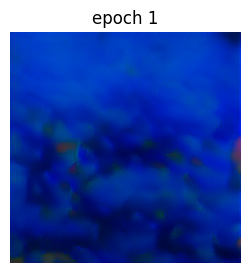

  0%|          | 0/2500 [00:00<?, ?it/s]

epoch 2/20 | train 9.4520 | 455.8s


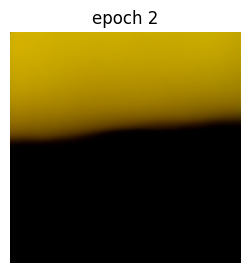

  0%|          | 0/2500 [00:00<?, ?it/s]

epoch 3/20 | train 8.6636 | 455.3s


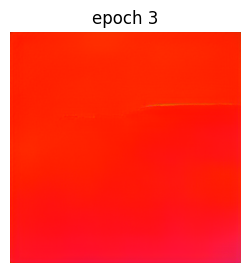

  0%|          | 0/2500 [00:00<?, ?it/s]

epoch 4/20 | train 8.2778 | 454.8s


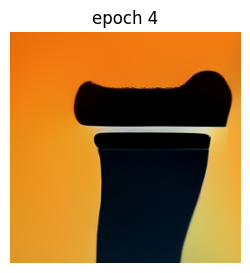

  0%|          | 0/2500 [00:00<?, ?it/s]

epoch 5/20 | train 7.9590 | 455.4s


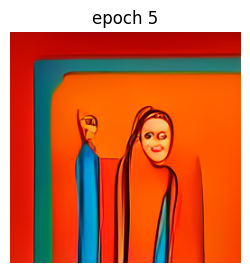

  0%|          | 0/2500 [00:00<?, ?it/s]

epoch 6/20 | train 7.5957 | 454.9s


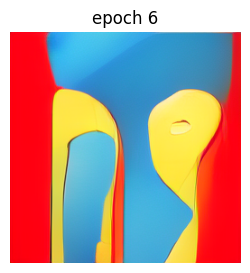

  0%|          | 0/2500 [00:00<?, ?it/s]

epoch 7/20 | train 7.0946 | 454.3s


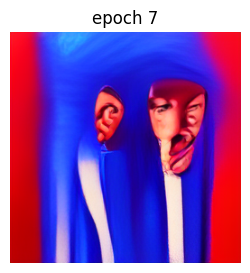

  0%|          | 0/2500 [00:00<?, ?it/s]

epoch 8/20 | train 6.4180 | 454.3s


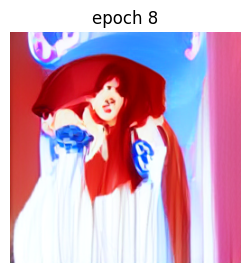

  0%|          | 0/2500 [00:00<?, ?it/s]

epoch 9/20 | train 5.5860 | 453.4s


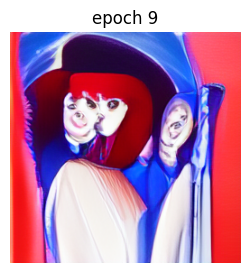

  0%|          | 0/2500 [00:00<?, ?it/s]

In [ ]:
vlm_cfg = VLMConfig()
train_cfg = TrainConfig()
with torch.enable_grad():
    model = train(train_cfg, vlm_cfg)

## Итог

CLIP-вход (семантика) + LlamaGen-выход (генерация). Сравните `results_janus/` с `results_vqonly/` из ноутбука 1 на том же числе эпох — гипотеза в том, что семантический энкодер на входе помогает модели лучше «понимать» исходную картинку, и редактирование обучается легче.

## Инференс на обученной модели

In [ ]:
CKPT = "checkpoints/janus_epoch_49.pt"      # поменяйте на нужный чекпоинт

infer_cfg = VLMConfig()
infer_model = VisionLanguageModel(infer_cfg, load_backbone=False).to(DEVICE)
infer_model.load_state_dict(torch.load(CKPT, map_location=DEVICE))
infer_model.eval()

infer_tokenizer = AutoTokenizer.from_pretrained(infer_cfg.lm_tokenizer, use_fast=True)
infer_tokenizer.pad_token = infer_tokenizer.eos_token
print("loaded", CKPT)

In [ ]:
# своя картинка + инструкция (или ex = get_eval_example())
ex = dict(image_path="berner.jpg", description="A photo of a bernese mountain dog puppy. ", prompt="Make the style cartoonish")

edited = sample_edit_image(infer_model, infer_tokenizer, device=DEVICE, **ex)
orig = center_crop_arr(Image.open(ex["image_path"]).convert("RGB"), 256)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(orig);   ax[0].set_title("input"); ax[0].axis("off")
ax[1].imshow(edited); ax[1].set_title(f"edit: {ex['prompt']}"); ax[1].axis("off")
plt.show()


Ничего нам не мешает совместить эти два подхода и передавать в модель и то и другое! Попробуем сделать это в третьем ноутбуке!